# GSE6477 — Analysis

**Goal:** Map Affymetrix probe IDs to HGNC gene symbols, collapse to a gene-level matrix.

**Sections**
1. Setup & data reload
2. GPL96 annotation table
3. Probe → gene symbol mapping
4. Gene-level matrix

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import GEOparse

os.makedirs("data/geo", exist_ok=True)
print("Libraries OK")

Libraries OK


In [2]:
# Reads from local cache
gse = GEOparse.get_GEO("GSE6477", destdir="data/geo/", silent=True)

parts = {
    name: gsm.table.set_index("ID_REF")["VALUE"].rename(name)
    for name, gsm in gse.gsms.items()
    if gsm.table is not None and not gsm.table.empty
}
expr = pd.DataFrame(parts).astype(float)

meta = pd.DataFrame({
    "title":  {n: g.metadata.get("title",  [""])[0] for n, g in gse.gsms.items()},
    "source": {n: g.metadata.get("source_name_ch1", [""])[0] for n, g in gse.gsms.items()},
}).reindex(expr.columns)

_map = {"normal": "Normal_PC", "mgus": "MGUS", "smoldering": "SMM",
        "newly diagnosed": "MM_New", "relapsed": "MM_Relapse"}
def _clean(src):
    s = str(src).lower()
    for key, label in _map.items():
        if key in s: return label
    return "Unknown"
meta["stage"] = meta["source"].map(_clean)

ORDER     = ["Normal_PC", "MGUS", "SMM", "MM_New", "MM_Relapse"]
PALETTE   = dict(zip(ORDER, sns.color_palette("Set2", len(ORDER))))
STAGE_COL = "stage"

expr_log = np.log2(expr + 1)
expr_log = expr_log[~expr_log.index.str.startswith("AFFX")]
print(f"expr_log: {expr_log.shape[0]:,} probes x {expr_log.shape[1]} samples")
print(f"Stages  : {dict(meta[STAGE_COL].value_counts()[ORDER])}")

expr_log: 22,215 probes x 162 samples
Stages  : {'Normal_PC': np.int64(15), 'MGUS': np.int64(21), 'SMM': np.int64(23), 'MM_New': np.int64(75), 'MM_Relapse': np.int64(28)}


---
## GPL96 annotation table

GEOparse downloads the platform annotation alongside the expression data.
GPL96 is the Affymetrix HG-U133A chip — 22,283 probes on the array.

In [3]:
gpl   = gse.gpls["GPL96"]
annot = gpl.table.copy()
print(f"Annotation rows   : {annot.shape[0]:,}")
print(f"Annotation columns: {annot.shape[1]}")
print()
print("All columns:")
for c in annot.columns:
    sample_val = str(annot[c].dropna().iloc[0])[:60] if annot[c].notna().any() else ""
    print(f"  {c:<35s}  e.g. {sample_val}")

Annotation rows   : 22,283
Annotation columns: 16

All columns:
  ID                                   e.g. 1007_s_at
  GB_ACC                               e.g. U48705
  SPOT_ID                              e.g. --Control
  Species Scientific Name              e.g. Homo sapiens
  Annotation Date                      e.g. Oct 6, 2014
  Sequence Type                        e.g. Exemplar sequence
  Sequence Source                      e.g. Affymetrix Proprietary Database
  Target Description                   e.g. U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Human receptor tyr
  Representative Public ID             e.g. U48705
  Gene Title                           e.g. discoidin domain receptor tyrosine kinase 1 /// microRNA 464
  Gene Symbol                          e.g. DDR1 /// MIR4640
  ENTREZ_GENE_ID                       e.g. 780 /// 100616237
  RefSeq Transcript ID                 e.g. NM_001202521 /// NM_001202522 /// NM_001202523 /// NM_001954
  Gene Ontology Biological Process   

---
## Probe → gene symbol mapping

GPL96 stores gene symbols in the `Gene Symbol` column.
Multi-gene probes look like `DDR1 /// MIR4640` — we take the first symbol.
Probes with no symbol (control or EST probes) are dropped.

In [4]:
# Locate the gene symbol column (handles minor naming variations)
sym_col = None
for candidate in ["Gene Symbol", "Gene_Symbol", "gene_symbol"]:
    if candidate in annot.columns:
        sym_col = candidate
        break

if sym_col is None:
    raise KeyError(f"Gene symbol column not found. Columns: {annot.columns.tolist()}")

print(f"Using column: '{sym_col}'")

# probe ID -> first gene symbol (split on " /// ")
probe2gene = (
    annot.set_index("ID")[sym_col]
    .fillna("")
    .str.split(" /// ")
    .str[0]
    .str.strip()
)

n_mapped   = (probe2gene != "").sum()
n_unmapped = (probe2gene == "").sum()
print(f"Probes with gene symbol : {n_mapped:,}")
print(f"Probes without (EST/ctrl): {n_unmapped:,}")

# Spot-check a few
print()
print("Sample mappings:")
for pid in ["1007_s_at", "204475_at", "211542_x_at", "200817_x_at"]:
    print(f"  {pid:<20s} -> {probe2gene.get(pid, "not found")}")

Using column: 'Gene Symbol'
Probes with gene symbol : 21,225
Probes without (EST/ctrl): 1,058

Sample mappings:
  1007_s_at            -> DDR1
  204475_at            -> MMP1
  211542_x_at          -> RPS10
  200817_x_at          -> RPS10


---
## Gene-level matrix

Multiple probes can map to the same gene.
Strategy: keep the probe with the **highest mean expression** across all samples
(most reliably detected signal). Drop probes with no gene symbol.

In [5]:
gene_labels = probe2gene.reindex(expr_log.index).fillna("")
mask        = gene_labels != ""
print(f"Probes in expr_log with a symbol: {mask.sum():,} / {len(mask):,}")

tmp          = expr_log[mask].copy()
tmp.index    = gene_labels[mask]        # rename rows to gene symbols
tmp["_mean"] = tmp.mean(axis=1)
tmp          = tmp.sort_values("_mean", ascending=False)
expr_genes   = tmp[~tmp.index.duplicated(keep="first")].drop(columns="_mean")

print(f"Unique genes kept    : {expr_genes.shape[0]:,}")
print(f"Duplicate probes dropped: {mask.sum() - expr_genes.shape[0]:,}")
print(f"Final matrix         : {expr_genes.shape[0]:,} genes x {expr_genes.shape[1]} samples")
expr_genes.iloc[:5, :5]

Probes in expr_log with a symbol: 21,215 / 22,215
Unique genes kept    : 13,237
Duplicate probes dropped: 7,978
Final matrix         : 13,237 genes x 162 samples


,GSM148911,GSM148912,GSM148914,GSM148915,GSM148916
Gene Symbol,,,,,
EEF1A1,15.458471,15.607475,15.648442,15.568045,15.728160
B2M,15.371300,15.823293,15.684529,15.411908,15.843651
RPL23A,15.491978,15.866820,15.480790,15.791926,15.391210
LOC101928826,15.768805,16.280118,15.018157,15.508816,15.626935
UBC,15.456804,15.973025,15.742020,15.475322,15.371436


In [6]:
top20 = expr_genes.var(axis=1).nlargest(20)
print("Top 20 most variable genes (log2 scale):")
for gene, var in top20.items():
    print(f"  {gene:<20s}  var = {var:.3f}")

Top 20 most variable genes (log2 scale):
  LAMP5                 var = 10.127
  IGHM                  var = 8.989
  abParts               var = 8.722
  CKAP2                 var = 8.425
  RPS4Y1                var = 8.294
  CD9                   var = 7.931
  EIF1AY                var = 7.651
  RNASE6                var = 7.559
  PMAIP1                var = 7.523
  IGKV1-37              var = 7.342
  EDNRB                 var = 7.255
  PCDH9                 var = 7.023
  AL928768.3            var = 6.821
  IGKV1OR2-108          var = 6.818
  DDX3Y                 var = 6.676
  LOC100293211          var = 6.606
  IGH                   var = 6.503
  NLGN4X                var = 6.348
  IGLL5                 var = 6.333
  RGS13                 var = 6.319


---
## Quick PCA sanity check

Re-run PCA on the gene-symbol matrix to confirm the mapping preserved the signal.

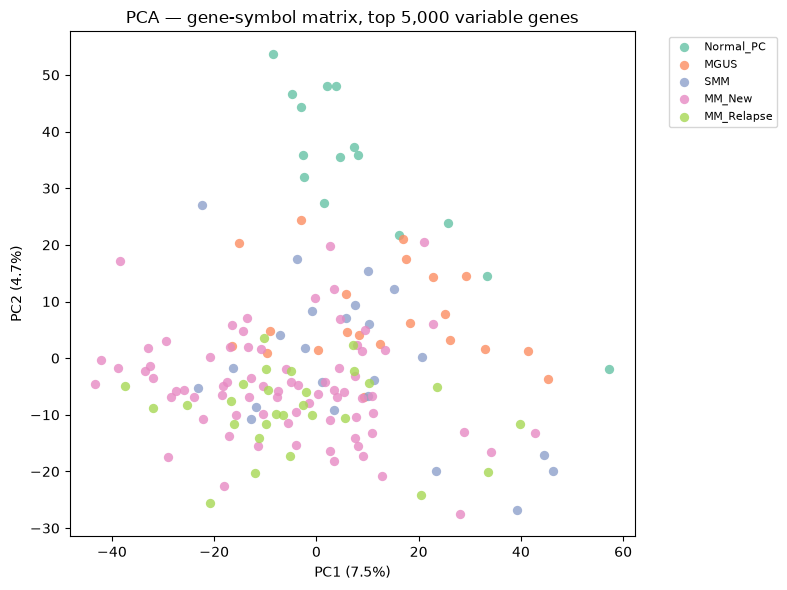

Variance explained:
  PC1: 7.5%
  PC2: 4.7%
  PC3: 3.0%
  PC4: 2.3%
  PC5: 2.1%
  PC6: 1.8%


In [7]:
top5k    = expr_genes.var(axis=1).nlargest(5_000).index
X        = expr_genes.loc[top5k].T.fillna(expr_genes.loc[top5k].median(axis=1))
X_sc     = StandardScaler().fit_transform(X)
pca      = PCA(n_components=6, random_state=42)
pcs      = pca.fit_transform(X_sc)
var_exp  = pca.explained_variance_ratio_ * 100

pc_df = pd.DataFrame(pcs[:, :2], index=expr_genes.columns, columns=["PC1","PC2"])
pc_df[STAGE_COL] = meta[STAGE_COL].reindex(pc_df.index).values

fig, ax = plt.subplots(figsize=(8, 6))
for stg in ORDER:
    sub = pc_df[pc_df[STAGE_COL] == stg]
    ax.scatter(sub.PC1, sub.PC2, label=stg,
               color=PALETTE.get(stg, "grey"), s=45, alpha=0.8, linewidths=0)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title("PCA — gene-symbol matrix, top 5,000 variable genes")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("Variance explained:")
for i, v in enumerate(var_exp, 1):
    print(f"  PC{i}: {v:.1f}%")

---
## Outlier removal

Drop any sample whose mean inter-sample Pearson r is > 2 SD below the cohort mean.

In [8]:
corr_mat = expr_genes.corr()
mean_r   = corr_mat.mean()
thresh   = mean_r.mean() - 2 * mean_r.std()
to_drop  = mean_r[mean_r < thresh].index.tolist()

print(f"Mean inter-sample r : {mean_r.mean():.3f} +/- {mean_r.std():.3f}")
print(f"Outlier threshold   : {thresh:.3f}")
print(f"Samples dropped     : {to_drop}")

expr_clean = expr_genes.drop(columns=to_drop)
meta_clean = meta.drop(index=[s for s in to_drop if s in meta.index])

print()
print(f"Clean matrix: {expr_clean.shape[0]:,} genes x {expr_clean.shape[1]} samples")
print(meta_clean[STAGE_COL].value_counts()[ORDER])

Mean inter-sample r : 0.829 +/- 0.022
Outlier threshold   : 0.786
Samples dropped     : ['GSM148983', 'GSM149035', 'GSM149037', 'GSM149039', 'GSM149041', 'GSM149042', 'GSM149043', 'GSM149045', 'GSM149046', 'GSM149047']

Clean matrix: 13,237 genes x 152 samples
stage
Normal_PC     14
MGUS          19
SMM           20
MM_New        73
MM_Relapse    26
Name: count, dtype: int64


---
## Differential expression

Pairwise comparisons along the progression axis:

| Comparison | Biology |
|---|---|
| Normal_PC → MGUS | First clonal transformation |
| MGUS → SMM | Smoldering progression |
| SMM → MM_New | Malignant conversion |
| MM_New → MM_Relapse | Treatment-driven evolution |

**Method:** Welch's t-test per gene + Benjamini-Hochberg FDR.  
**Significant:** adj_p < 0.05 AND |log2FC| > 1 (≥ 2-fold change).  
**log2FC** = mean(later stage) − mean(earlier stage) — positive = upregulated in progression.

In [9]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def run_de(expr, meta, stage_col, group_a, group_b):
    """Welch t-test + BH FDR. Returns DataFrame sorted by adj_pval."""
    a_idx = meta[meta[stage_col] == group_a].index
    b_idx = meta[meta[stage_col] == group_b].index
    a = expr[a_idx].values   # shape: genes x n_a
    b = expr[b_idx].values   # shape: genes x n_b

    log2fc        = b.mean(axis=1) - a.mean(axis=1)
    _, pvals      = stats.ttest_ind(b.T, a.T, equal_var=False)
    _, adj_pvals, _, _ = multipletests(pvals, method="fdr_bh")

    df = pd.DataFrame(
        {"log2FC": log2fc, "pval": pvals, "adj_pval": adj_pvals},
        index=expr.index
    )
    df["significant"] = (df["adj_pval"] < 0.05) & (df["log2FC"].abs() > 1)
    return df.sort_values("adj_pval")

print("run_de() ready")

run_de() ready


In [10]:
COMPARISONS = [
    ("Normal_PC", "MGUS",       "Normal_PC -> MGUS"),
    ("MGUS",      "SMM",        "MGUS -> SMM"),
    ("SMM",       "MM_New",     "SMM -> MM_New"),
    ("MM_New",    "MM_Relapse", "MM_New -> MM_Relapse"),
]

de_results = {}
for a, b, label in COMPARISONS:
    de_results[label] = run_de(expr_clean, meta_clean, STAGE_COL, a, b)

print(f"{"Comparison":<28}  {"Up":>6}  {"Down":>6}  {"Total":>6}")
print("-" * 54)
for label, df in de_results.items():
    up = (df["significant"] & (df["log2FC"] > 0)).sum()
    dn = (df["significant"] & (df["log2FC"] < 0)).sum()
    print(f"{label:<28}  {up:6d}  {dn:6d}  {up+dn:6d}")

Comparison                        Up    Down   Total
------------------------------------------------------
Normal_PC -> MGUS                238     238     476
MGUS -> SMM                        0       0       0
SMM -> MM_New                      1       2       3
MM_New -> MM_Relapse               0       0       0


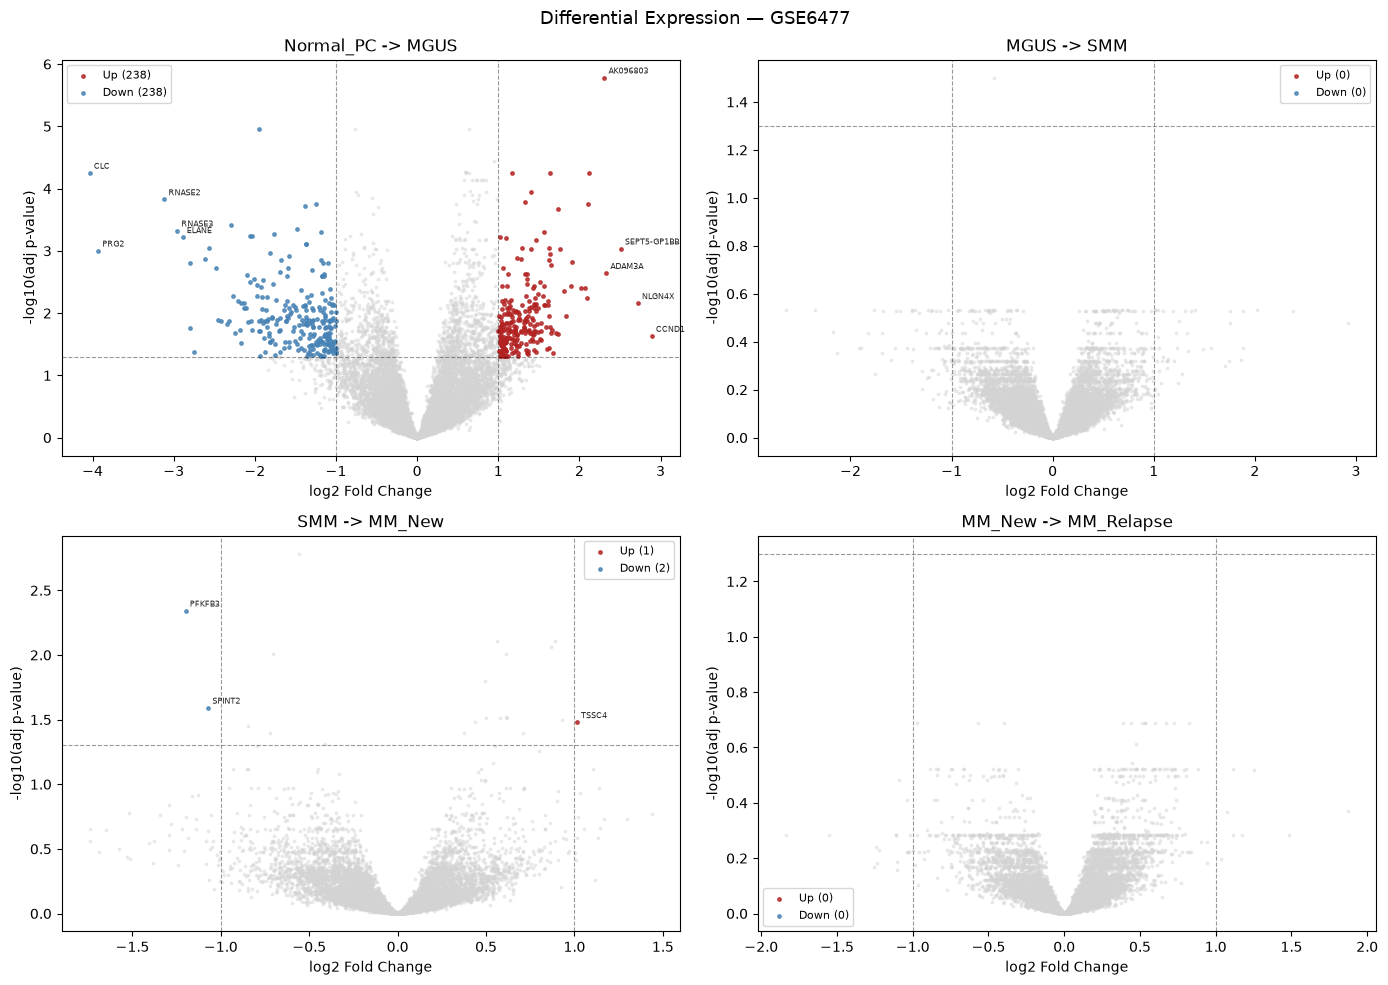

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (label, df) in zip(axes, de_results.items()):
    y   = -np.log10(df["adj_pval"].clip(lower=1e-300))
    ns  = df[~df["significant"]]
    up  = df[ df["significant"] & (df["log2FC"] > 0)]
    dn  = df[ df["significant"] & (df["log2FC"] < 0)]

    ax.scatter(ns["log2FC"], y[ns.index], c="lightgrey", s=3, alpha=0.4)
    ax.scatter(up["log2FC"], y[up.index], c="firebrick", s=6, alpha=0.8, label=f"Up ({len(up)})")
    ax.scatter(dn["log2FC"], y[dn.index], c="steelblue", s=6, alpha=0.8, label=f"Down ({len(dn)})")

    ax.axhline(-np.log10(0.05), color="k", lw=0.8, ls="--", alpha=0.4)
    ax.axvline( 1, color="k", lw=0.8, ls="--", alpha=0.4)
    ax.axvline(-1, color="k", lw=0.8, ls="--", alpha=0.4)

    for sub in [up.nlargest(5, "log2FC"), dn.nsmallest(5, "log2FC")]:
        for gene, row in sub.iterrows():
            ax.annotate(gene, xy=(row["log2FC"], y[gene]),
                        fontsize=6, alpha=0.85,
                        xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel("log2 Fold Change")
    ax.set_ylabel("-log10(adj p-value)")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Differential Expression — GSE6477", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
for label, df in de_results.items():
    sig    = df[df["significant"]]
    top_up = sig[sig["log2FC"] > 0].nlargest(8, "log2FC")
    top_dn = sig[sig["log2FC"] < 0].nsmallest(8, "log2FC")

    print()
    print(f"=== {label} ===")
    print(f"  Upregulated   ({len(sig[sig.log2FC>0])} total):")
    for gene, row in top_up.iterrows():
        print(f"    {gene:<18s}  log2FC={row.log2FC:+.2f}  adj_p={row.adj_pval:.2e}")
    print(f"  Downregulated ({len(sig[sig.log2FC<0])} total):")
    for gene, row in top_dn.iterrows():
        print(f"    {gene:<18s}  log2FC={row.log2FC:+.2f}  adj_p={row.adj_pval:.2e}")


=== Normal_PC -> MGUS ===
  Upregulated   (238 total):
    CCND1               log2FC=+2.89  adj_p=2.33e-02
    NLGN4X              log2FC=+2.72  adj_p=6.95e-03
    SEPT5-GP1BB         log2FC=+2.51  adj_p=9.20e-04
    ADAM3A              log2FC=+2.33  adj_p=2.28e-03
    AK096803            log2FC=+2.31  adj_p=1.65e-06
    GPT                 log2FC=+2.12  adj_p=5.61e-05
    POLD4               log2FC=+2.10  adj_p=1.74e-04
    AV8S2A1N1T          log2FC=+2.10  adj_p=5.68e-03
  Downregulated (238 total):
    CLC                 log2FC=-4.03  adj_p=5.61e-05
    PRG2                log2FC=-3.93  adj_p=9.97e-04
    RNASE2              log2FC=-3.11  adj_p=1.49e-04
    RNASE3              log2FC=-2.96  adj_p=4.74e-04
    ELANE               log2FC=-2.89  adj_p=6.05e-04
    PRG3                log2FC=-2.80  adj_p=1.57e-03
    P2RY13              log2FC=-2.80  adj_p=1.70e-02
    MAFB                log2FC=-2.74  adj_p=4.15e-02

=== MGUS -> SMM ===
  Upregulated   (0 total):
  Downregulated (0 

In [13]:
import os
os.makedirs("results", exist_ok=True)

for label, df in de_results.items():
    fname = label.replace(" -> ", "_vs_").replace(" ", "_") + "_DE.csv"
    df.to_csv(f"results/{fname}")
    print(f"Saved results/{fname}")

Saved results/Normal_PC_vs_MGUS_DE.csv
Saved results/MGUS_vs_SMM_DE.csv
Saved results/SMM_vs_MM_New_DE.csv
Saved results/MM_New_vs_MM_Relapse_DE.csv


---
## Pathway enrichment analysis

Identify biological processes enriched in the differentially expressed genes.

**Two methods:**
- **Enrichr ORA** — over-representation test on the significant gene list (Normal_PC → MGUS has 476 genes; the tool submits them to the Enrichr web API).
- **Pre-ranked GSEA** — ranks *all* ~13k genes by log2FC and slides Hallmark gene sets across the ranking. Useful for comparisons with few/no ORA-significant genes.

**Databases:** MSigDB_Hallmark_2020 · KEGG_2021_Human

In [14]:
import gseapy as gp

LABEL    = "Normal_PC -> MGUS"
df_mgus  = de_results[LABEL]
sig      = df_mgus[df_mgus["significant"]]
up_genes = sig[sig["log2FC"] > 0].index.tolist()
dn_genes = sig[sig["log2FC"] < 0].index.tolist()

print(f"Normal_PC -> MGUS  |  Up: {len(up_genes)}  Down: {len(dn_genes)}")

GENE_SETS = ["MSigDB_Hallmark_2020", "KEGG_2021_Human"]

enr_up = gp.enrichr(gene_list=up_genes,  gene_sets=GENE_SETS,
                     organism="human", cutoff=0.05, verbose=False)
enr_dn = gp.enrichr(gene_list=dn_genes, gene_sets=GENE_SETS,
                     organism="human", cutoff=0.05, verbose=False)

def top_terms(enr_obj, db, n=10):
    res = enr_obj.results
    res = res[res["Gene_set"] == db].copy()
    res = res[res["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
    return res[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(n)

print("\n--- Up-regulated (Hallmark) ---")
print(top_terms(enr_up, "MSigDB_Hallmark_2020").to_string(index=False))
print("\n--- Down-regulated (Hallmark) ---")
print(top_terms(enr_dn, "MSigDB_Hallmark_2020").to_string(index=False))


Normal_PC -> MGUS  |  Up: 238  Down: 238

--- Up-regulated (Hallmark) ---
Empty DataFrame
Columns: [Term, Overlap, Adjusted P-value, Genes]
Index: []

--- Down-regulated (Hallmark) ---
                             Term Overlap  Adjusted P-value                                                                                   Genes
                       Complement  16/200      9.726627e-08 C1QA;CR2;FCER1G;C1S;CTSL;APOC1;S100A12;CTSH;ADAM9;CD36;S100A9;CTSC;LGMN;CTSB;HSPA1A;LTF
           Estrogen Response Late  14/200      2.659240e-06       DUSP2;CLIC3;IGFBP4;EMP2;KLF4;CXCL14;CXCL12;FABP5;PRKAR2B;TFF3;CD9;SGK1;S100A9;LTF
                      Coagulation  11/138      8.775775e-06                                   CFD;C1QA;ANXA1;C1S;APOC1;ADAM9;CTSH;CD9;A2M;LGMN;CTSB
Epithelial Mesenchymal Transition  13/200      8.775775e-06        ITGB1;VCAM1;CXCL8;IGFBP4;SAT1;GLIPR1;DAB2;CXCL12;CDH11;PMP22;COL6A3;SPOCK1;TGFBI
         IL-6/JAK/STAT3 Signaling    8/87      7.627466e-05                

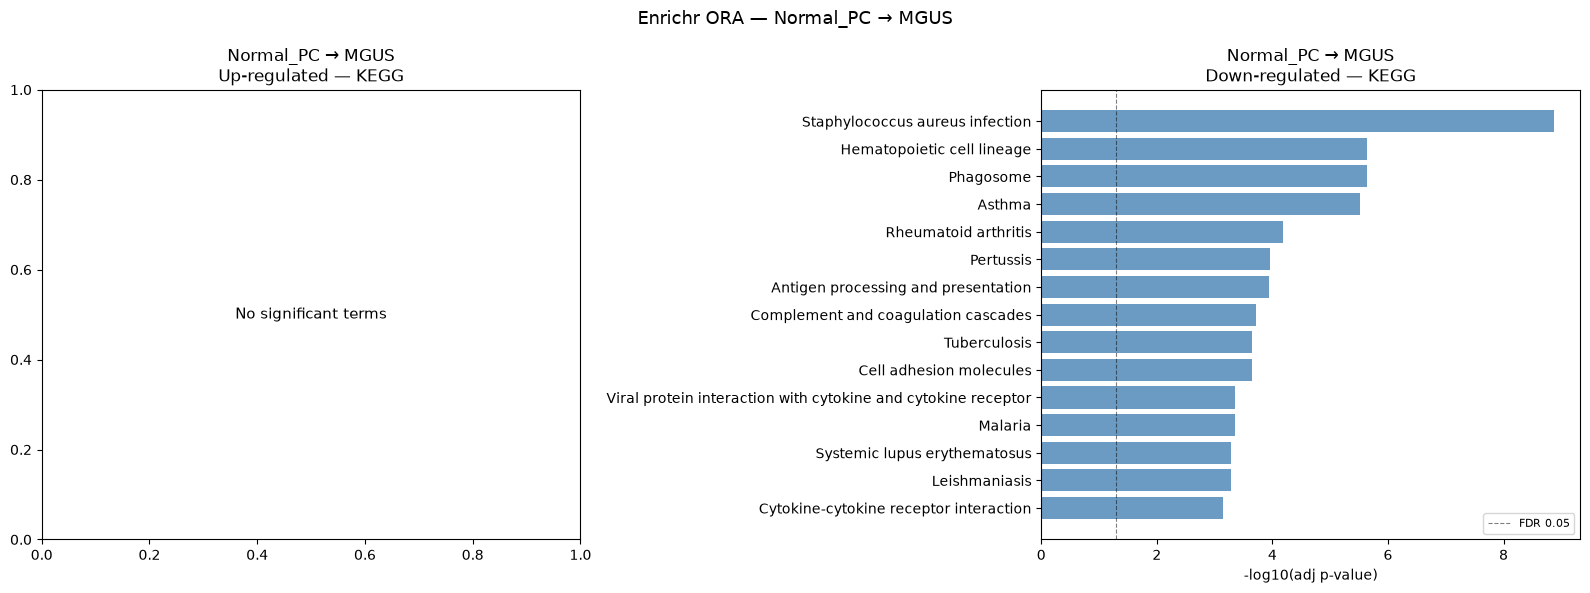

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, enr, direction, color in [
    (axes[0], enr_up, "Up-regulated",   "firebrick"),
    (axes[1], enr_dn, "Down-regulated", "steelblue"),
]:
    res = enr.results.copy()
    res = res[res["Gene_set"] == "KEGG_2021_Human"]
    res = res[res["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value").head(15)

    if res.empty:
        ax.text(0.5, 0.5, "No significant terms", ha="center", va="center",
                transform=ax.transAxes, fontsize=11)
        ax.set_title(f"Normal_PC → MGUS\n{direction} — KEGG")
        continue

    y_vals = -np.log10(res["Adjusted P-value"].clip(lower=1e-300))
    bars   = ax.barh(res["Term"], y_vals, color=color, alpha=0.8)
    ax.axvline(-np.log10(0.05), color="k", ls="--", lw=0.8, alpha=0.5, label="FDR 0.05")
    ax.set_xlabel("-log10(adj p-value)")
    ax.set_title(f"Normal_PC → MGUS\n{direction} — KEGG")
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.suptitle("Enrichr ORA — Normal_PC → MGUS", fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
print("Running pre-ranked GSEA (Hallmark, 100 permutations)…")
print("This takes ~1-2 min on first run (downloads Hallmark gene sets).\n")

gsea_results = {}
for a, b, label in COMPARISONS:
    rnk = de_results[label]["log2FC"].dropna().sort_values(ascending=False)
    try:
        res = gp.prerank(
            rnk            = rnk,
            gene_sets      = "MSigDB_Hallmark_2020",
            threads        = 1,          # avoid multiprocessing issues on Windows
            min_size       = 15,
            max_size       = 500,
            permutation_num= 100,
            seed           = 42,
            verbose        = False,
        )
        gsea_results[label] = res.res2d.copy()
        sig = (res.res2d["FDR q-val"] < 0.25).sum()
        print(f"  {label:<28}: {sig:3d} significant sets (FDR < 0.25)")
    except Exception as e:
        print(f"  {label:<28}: failed — {e}")
        gsea_results[label] = None


Running pre-ranked GSEA (Hallmark, 100 permutations)…
This takes ~1-2 min on first run (downloads Hallmark gene sets).

  Normal_PC -> MGUS           :  27 significant sets (FDR < 0.25)
  MGUS -> SMM                 :  20 significant sets (FDR < 0.25)
  SMM -> MM_New               :  34 significant sets (FDR < 0.25)
  MM_New -> MM_Relapse        :  24 significant sets (FDR < 0.25)


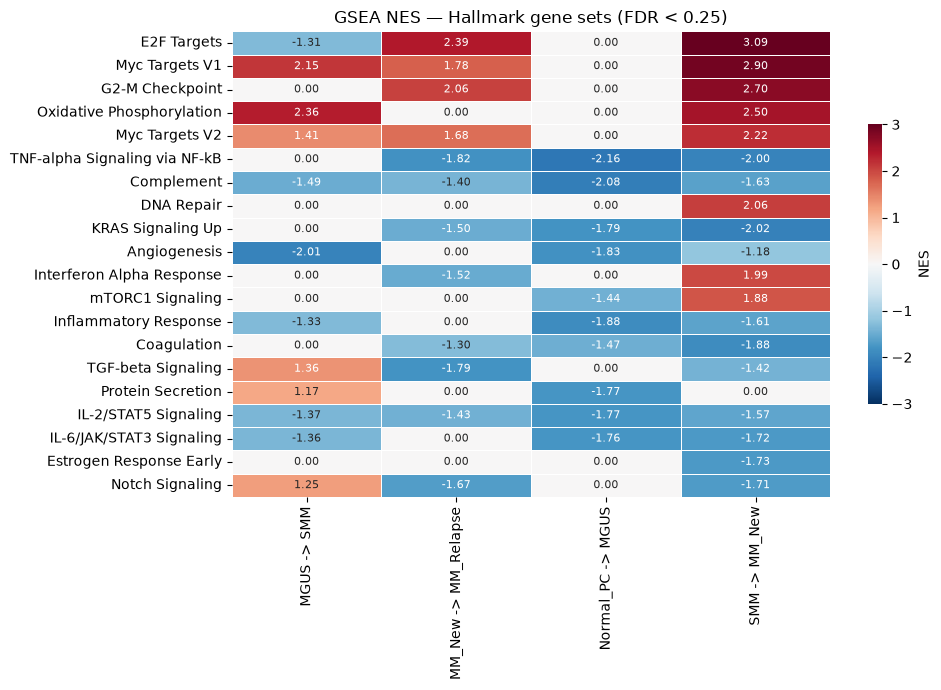

In [17]:
valid = {k: v for k, v in gsea_results.items() if v is not None}

if not valid:
    print("No GSEA results to plot.")
else:
    # Collect top gene sets per comparison (FDR < 0.25)
    rows = []
    for label, df in valid.items():
        top = df[df["FDR q-val"] < 0.25].copy()
        top["comparison"] = label
        rows.append(top)

    if rows:
        all_top = pd.concat(rows, ignore_index=True)
        # Pivot: gene sets as rows, comparisons as columns, NES as values
        pivot = all_top.pivot_table(index="Term", columns="comparison",
                                     values="NES", aggfunc="first").fillna(0)

        # Keep top 20 gene sets by max |NES|
        pivot = pivot.loc[pivot.abs().max(axis=1).nlargest(20).index]

        fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*2.5), 7))
        sns.heatmap(pivot, cmap="RdBu_r", center=0, vmin=-3, vmax=3,
                    linewidths=0.4, annot=True, fmt=".2f", annot_kws={"size": 8},
                    cbar_kws={"label": "NES", "shrink": 0.6}, ax=ax)
        ax.set_title("GSEA NES — Hallmark gene sets (FDR < 0.25)")
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        print("No gene sets passed FDR < 0.25 in any comparison.")


In [18]:
import os
os.makedirs("results/pathways", exist_ok=True)

enr_up.results.to_csv("results/pathways/Normal_PC_vs_MGUS_ORA_up.csv",   index=False)
enr_dn.results.to_csv("results/pathways/Normal_PC_vs_MGUS_ORA_down.csv", index=False)
print("Saved ORA results.")

for label, df in gsea_results.items():
    if df is None:
        continue
    fname = label.replace(" -> ", "_vs_").replace(" ", "_") + "_GSEA_Hallmark.csv"
    df.to_csv(f"results/pathways/{fname}", index=False)
    print(f"Saved results/pathways/{fname}")


Saved ORA results.
Saved results/pathways/Normal_PC_vs_MGUS_GSEA_Hallmark.csv
Saved results/pathways/MGUS_vs_SMM_GSEA_Hallmark.csv
Saved results/pathways/SMM_vs_MM_New_GSEA_Hallmark.csv
Saved results/pathways/MM_New_vs_MM_Relapse_GSEA_Hallmark.csv


---
## Purity check — granulocyte/eosinophil contamination

The top down-regulated genes in Normal_PC → MGUS (`CLC`, `PRG2`, `PRG3`, `RNASE2`, `RNASE3`, `ELANE`) and
the enriched down pathways (Complement, Phagosome, Antigen processing, Hematopoietic cell lineage) are
classic **granulocyte / eosinophil / neutrophil** markers — not plasma-cell biology.

Normal bone-marrow aspirates naturally carry more contaminating myeloid cells than a diseased marrow
dominated by an expanding plasma-cell clone, even after CD138 sorting. If Normal_PC samples score higher
on an independent granulocyte marker panel, that supports a **purity confound** rather than a true
myeloma-progression signal for the "down-regulated" half of the DE list.

**Panel** (canonical neutrophil/eosinophil granule + surface markers, independent of the DE hit list above):
`ELANE, MPO, PRTN3, CTSG, RNASE2, RNASE3, PRG2, CLC, S100A8, S100A9, FCGR3B, ITGAM`

In [19]:
GRANULOCYTE_MARKERS = [
    "ELANE", "MPO", "PRTN3", "CTSG",       # neutrophil primary granule
    "RNASE2", "RNASE3", "PRG2", "CLC",     # eosinophil granule
    "S100A8", "S100A9", "FCGR3B", "ITGAM", # myeloid / neutrophil surface
]

present = [g for g in GRANULOCYTE_MARKERS if g in expr_clean.index]
missing = [g for g in GRANULOCYTE_MARKERS if g not in expr_clean.index]
print(f"Markers found in matrix: {len(present)} / {len(GRANULOCYTE_MARKERS)}")
if missing:
    print(f"Not in gene matrix: {missing}")

# Per-gene z-score across samples, then average across the panel -> one score per sample
marker_expr = expr_clean.loc[present]
marker_z    = marker_expr.sub(marker_expr.mean(axis=1), axis=0).div(marker_expr.std(axis=1), axis=0)
gran_score  = marker_z.mean(axis=0)

score_df = pd.DataFrame({"granulocyte_score": gran_score})
score_df[STAGE_COL] = meta_clean[STAGE_COL].reindex(score_df.index)

print()
print("Mean granulocyte score by stage:")
print(score_df.groupby(STAGE_COL)["granulocyte_score"].mean().reindex(ORDER).to_string())

Markers found in matrix: 12 / 12

Mean granulocyte score by stage:
stage
Normal_PC     1.693590
MGUS          0.306593
SMM           0.073633
MM_New       -0.324600
MM_Relapse   -0.281245


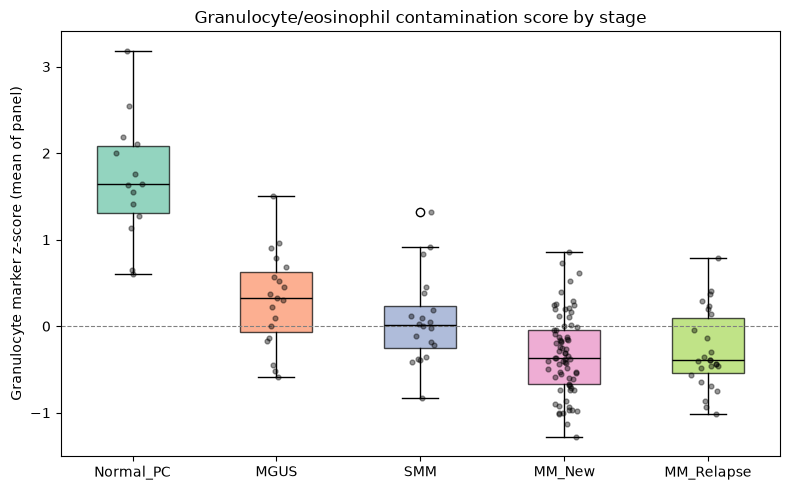

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
data = [score_df[score_df[STAGE_COL] == s]["granulocyte_score"].values for s in ORDER]

bp = ax.boxplot(data, patch_artist=True, tick_labels=ORDER,
                medianprops=dict(color="black"))
for patch, stg in zip(bp["boxes"], ORDER):
    patch.set_facecolor(PALETTE.get(stg, "grey"))
    patch.set_alpha(0.7)

rng = np.random.default_rng(0)
for i, s in enumerate(ORDER, start=1):
    vals = score_df[score_df[STAGE_COL] == s]["granulocyte_score"].values
    jitter = rng.normal(0, 0.05, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color="black", s=12, alpha=0.4, zorder=3)

ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_ylabel("Granulocyte marker z-score (mean of panel)")
ax.set_title("Granulocyte/eosinophil contamination score by stage")
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import mannwhitneyu

a = score_df[score_df[STAGE_COL] == "Normal_PC"]["granulocyte_score"]
b = score_df[score_df[STAGE_COL] == "MGUS"]["granulocyte_score"]

u_stat, p_val = mannwhitneyu(a, b, alternative="two-sided")
print(f"Normal_PC (n={len(a)}): mean={a.mean():.3f}  median={a.median():.3f}")
print(f"MGUS      (n={len(b)}): mean={b.mean():.3f}  median={b.median():.3f}")
print(f"Mann-Whitney U p-value: {p_val:.2e}")

print()
if p_val < 0.05 and a.mean() > b.mean():
    print("-> Normal_PC samples show a significantly higher granulocyte signature than MGUS.")
    print("   This supports a purity-confound interpretation for the down-regulated DE genes:")
    print("   part of that signature likely reflects sample composition, not myeloma biology.")
elif p_val < 0.05:
    print("-> Significant difference, but MGUS scores higher (unexpected direction for a purity confound).")
else:
    print("-> No significant difference detected — purity confound is less likely to explain the DE signal.")

Normal_PC (n=14): mean=1.694  median=1.643
MGUS      (n=19): mean=0.307  median=0.322
Mann-Whitney U p-value: 1.34e-05

-> Normal_PC samples show a significantly higher granulocyte signature than MGUS.
   This supports a purity-confound interpretation for the down-regulated DE genes:
   part of that signature likely reflects sample composition, not myeloma biology.


---
## Flagging confounded genes

The Mann-Whitney test above confirms Normal_PC samples carry more granulocyte contamination than MGUS.
To turn that into an actionable flag, correlate each significant Normal_PC → MGUS gene's expression
(across all 152 clean samples) with the per-sample granulocyte score computed earlier.

A down-regulated gene that also tracks tightly with the granulocyte score (|r| > 0.5) is more likely
explained by sample composition than by true plasma-cell biology, and is marked `purity_flag = True`
in the saved results.

In [22]:
CORR_THRESH = 0.5

df_mgus  = de_results["Normal_PC -> MGUS"].copy()
sig_idx  = df_mgus[df_mgus["significant"]].index

gran_corr = expr_clean.loc[sig_idx].apply(lambda row: row.corr(score_df["granulocyte_score"]), axis=1)

df_mgus["gran_corr"]   = np.nan
df_mgus.loc[sig_idx, "gran_corr"] = gran_corr
df_mgus["purity_flag"] = (
    df_mgus["significant"]
    & (df_mgus["log2FC"] < 0)
    & (df_mgus["gran_corr"].abs() > CORR_THRESH)
)

de_results["Normal_PC -> MGUS"] = df_mgus
df_mgus.to_csv("results/Normal_PC_vs_MGUS_DE.csv")

n_down    = (df_mgus["significant"] & (df_mgus["log2FC"] < 0)).sum()
n_flagged = df_mgus["purity_flag"].sum()
print(f"Down-regulated significant genes            : {n_down}")
print(f"Flagged as likely purity confound (|r| > {CORR_THRESH}): {n_flagged}")
print()
print("Top flagged genes (highest correlation with granulocyte score):")
print(df_mgus[df_mgus["purity_flag"]].sort_values("gran_corr", ascending=False)[["log2FC", "adj_pval", "gran_corr"]].head(15).to_string())

Down-regulated significant genes            : 238
Flagged as likely purity confound (|r| > 0.5): 94

Top flagged genes (highest correlation with granulocyte score):
               log2FC  adj_pval  gran_corr
Gene Symbol                               
DEFA1       -2.266912  0.005396   0.892839
RNASE2      -3.114914  0.000149   0.872256
DEFA4       -1.488463  0.008936   0.853420
S100A12     -1.375469  0.013011   0.850309
ELANE       -2.890397  0.000605   0.839782
LTF         -2.414879  0.013147   0.837844
S100A9      -1.439014  0.025242   0.813937
S100A8      -1.613438  0.013434   0.802920
RNASE3      -2.956797  0.000474   0.794227
MPO         -1.330823  0.012712   0.791275
FCER1G      -1.174286  0.013147   0.786176
PRG2        -3.930319  0.000997   0.782872
BPI         -1.854343  0.013434   0.752172
CAMP        -1.975166  0.005329   0.750368
LYZ         -1.824929  0.023548   0.749543


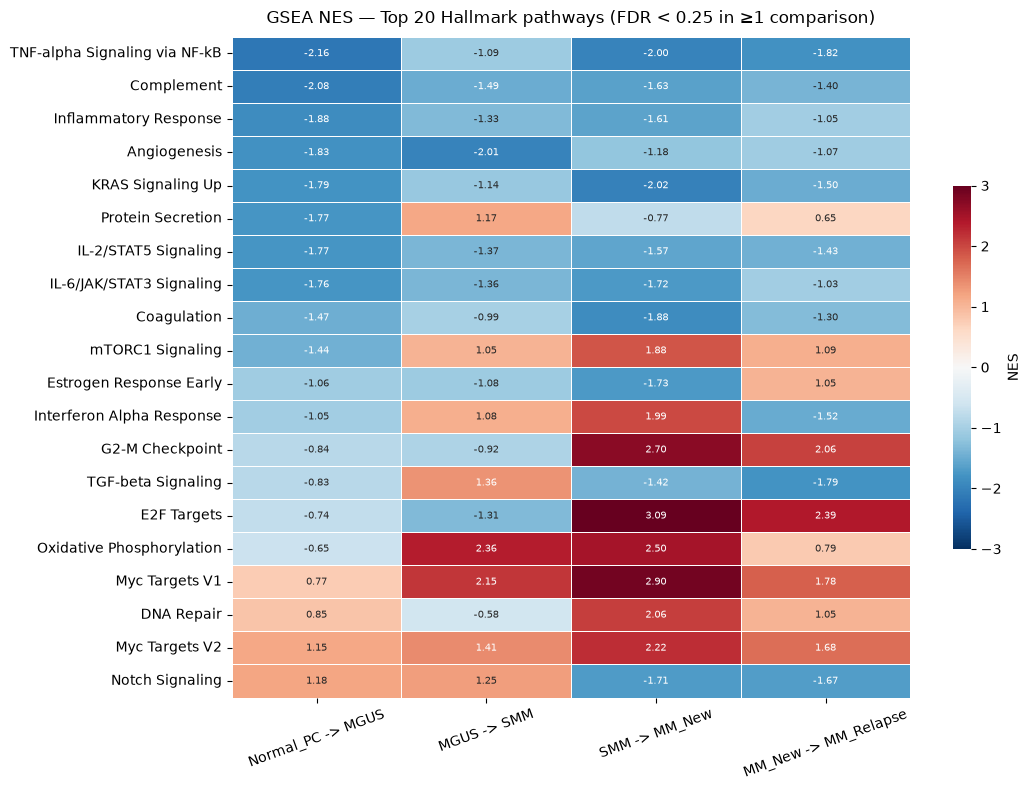

Saved results/figures/NES_heatmap.png


In [23]:
import os
os.makedirs("results/figures", exist_ok=True)

GSEA_FILES = {
    "Normal_PC -> MGUS":   "results/pathways/Normal_PC_vs_MGUS_GSEA_Hallmark.csv",
    "MGUS -> SMM":          "results/pathways/MGUS_vs_SMM_GSEA_Hallmark.csv",
    "SMM -> MM_New":        "results/pathways/SMM_vs_MM_New_GSEA_Hallmark.csv",
    "MM_New -> MM_Relapse": "results/pathways/MM_New_vs_MM_Relapse_GSEA_Hallmark.csv",
}
all_gsea = {
    label: pd.read_csv(path).set_index("Term")
    for label, path in GSEA_FILES.items()
}

sig_terms = set()
for df in all_gsea.values():
    sig_terms.update(df[df["FDR q-val"] < 0.25].index.tolist())

nes_df   = pd.DataFrame({lbl: df["NES"] for lbl, df in all_gsea.items()}).fillna(0)
nes_sig  = nes_df.loc[nes_df.index.isin(sig_terms)]
top20    = nes_sig.abs().max(axis=1).nlargest(20).index
nes_plot = nes_sig.loc[top20].sort_values("Normal_PC -> MGUS")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    nes_plot, cmap="RdBu_r", center=0, vmin=-3, vmax=3,
    linewidths=0.5, linecolor="white",
    annot=True, fmt=".2f", annot_kws={"size": 7.5},
    cbar_kws={"label": "NES", "shrink": 0.55}, ax=ax,
)
ax.set_title("GSEA NES — Top 20 Hallmark pathways (FDR < 0.25 in ≥1 comparison)", pad=10)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("results/figures/NES_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/NES_heatmap.png")


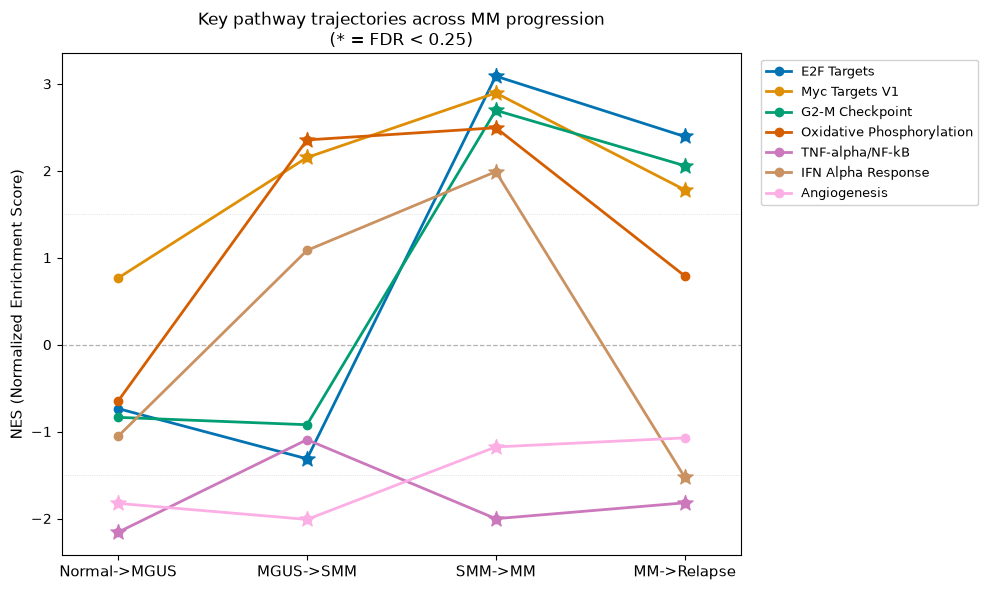

Saved results/figures/pathway_trajectory.png


In [24]:
PATHWAY_MAP = {
    "E2F Targets":               "E2F Targets",
    "Myc Targets V1":            "Myc Targets V1",
    "G2-M Checkpoint":           "G2-M Checkpoint",
    "Oxidative Phosphorylation": "Oxidative Phosphorylation",
    "TNF-alpha/NF-kB":           "TNF-alpha Signaling via NF-kB",
    "IFN Alpha Response":        "Interferon Alpha Response",
    "Angiogenesis":              "Angiogenesis",
}

COMP_ORDER = list(GSEA_FILES.keys())
XLABELS    = ["Normal->MGUS", "MGUS->SMM", "SMM->MM", "MM->Relapse"]

traj   = {name: [] for name in PATHWAY_MAP}
is_sig = {name: [] for name in PATHWAY_MAP}
for comp in COMP_ORDER:
    df_c = all_gsea[comp]
    for short, term in PATHWAY_MAP.items():
        if term in df_c.index:
            traj[short].append(df_c.loc[term, "NES"])
            is_sig[short].append(df_c.loc[term, "FDR q-val"] < 0.25)
        else:
            traj[short].append(np.nan)
            is_sig[short].append(False)

palette = sns.color_palette("colorblind", len(PATHWAY_MAP))
x = np.arange(len(COMP_ORDER))

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, vals) in enumerate(traj.items()):
    c = palette[i]
    ax.plot(x, vals, "-o", color=c, lw=2.0, ms=6, label=name, zorder=3)
    for j, (v, sig) in enumerate(zip(vals, is_sig[name])):
        if sig and not np.isnan(v):
            ax.scatter(j, v, marker="*", s=130, color=c, zorder=4)

ax.axhline(0,    color="grey", lw=0.9, ls="--", alpha=0.6)
ax.axhline( 1.5, color="grey", lw=0.5, ls=":",  alpha=0.4)
ax.axhline(-1.5, color="grey", lw=0.5, ls=":",  alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(XLABELS, fontsize=11)
ax.set_ylabel("NES (Normalized Enrichment Score)", fontsize=11)
ax.set_title("Key pathway trajectories across MM progression\n(* = FDR < 0.25)", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.9)
ax.set_xlim(-0.3, len(x) - 0.7)
plt.tight_layout()
plt.savefig("results/figures/pathway_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/pathway_trajectory.png")


---
## Key gene expression across stages

Boxplots of log2 expression for genes that appear in the leading-edge lists of the strongest GSEA hits.

- **CCND1** — top up-regulated gene at Normal_PC → MGUS; cyclin that starts the cell cycle
- **MYC** — master growth driver; Myc Targets V1 is the #2 GSEA hit at SMM → MM_New
- **TOP2A / MKI67 / CCNB2 / CDK1** — core E2F and G2-M machinery; all climb steeply at the SMM → MM_New transition


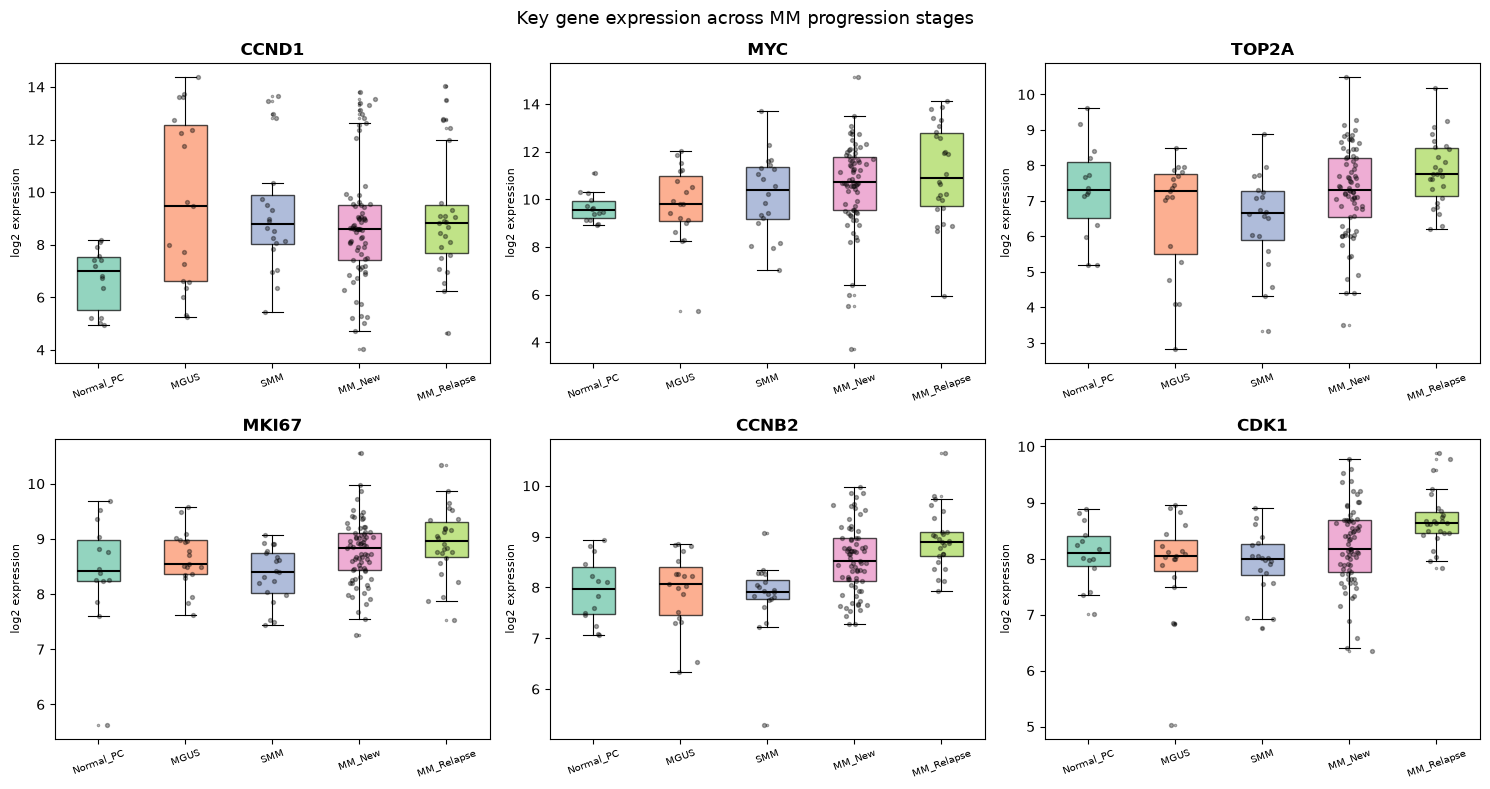

Saved results/figures/key_gene_boxplots.png


In [25]:
KEY_GENES = ["CCND1", "MYC", "TOP2A", "MKI67", "CCNB2", "CDK1"]

present = [g for g in KEY_GENES if g in expr_clean.index]
missing = [g for g in KEY_GENES if g not in expr_clean.index]
if missing:
    print(f"Not found in matrix: {missing}")

ncols = 3
nrows = (len(present) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()
rng = np.random.default_rng(1)

for ax, gene in zip(axes, present):
    data = [
        expr_clean.loc[gene, meta_clean[meta_clean[STAGE_COL] == s].index].values
        for s in ORDER
    ]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=ORDER,
                    medianprops=dict(color="black", lw=1.5),
                    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                    flierprops=dict(marker=".", ms=3, alpha=0.4))
    for patch, stg in zip(bp["boxes"], ORDER):
        patch.set_facecolor(PALETTE.get(stg, "grey"))
        patch.set_alpha(0.7)
    for i, (stg, vals) in enumerate(zip(ORDER, data), start=1):
        jitter = rng.normal(0, 0.07, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="black", s=8, alpha=0.35, zorder=3)
    ax.set_title(gene, fontsize=12, fontweight="bold")
    ax.set_ylabel("log2 expression", fontsize=8)
    ax.tick_params(axis="x", labelsize=7, rotation=20)

for ax in axes[len(present):]:
    ax.set_visible(False)

plt.suptitle("Key gene expression across MM progression stages", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/key_gene_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/key_gene_boxplots.png")


---
## UMAP — sample-level visualisation

UMAP squashes 5,000 gene dimensions down to 2 so we can plot all 152 samples on one chart. Each dot is one patient, coloured by disease stage.

If the stages form clean separate islands the 5-class structure is real and a classifier will work well. Some overlap between adjacent stages (e.g. SMM and MM_New) is expected — those transitions are gradual, not a hard boundary.


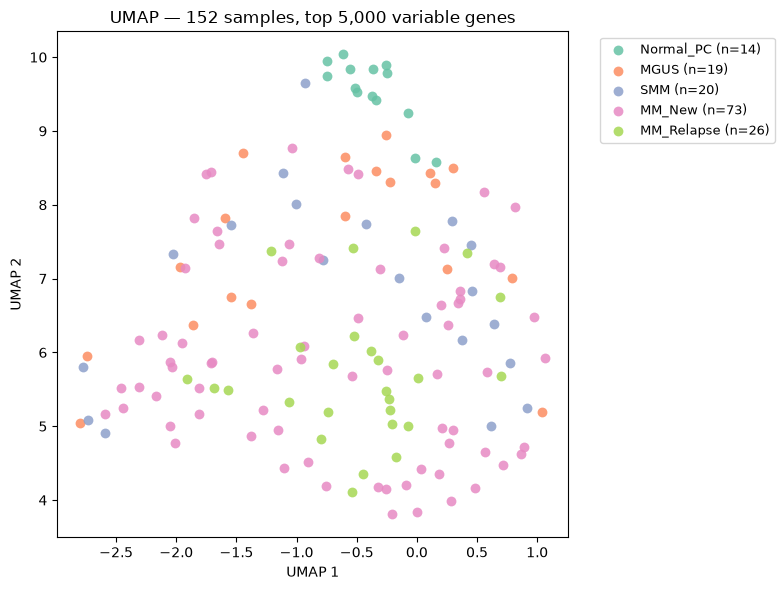

Saved results/figures/UMAP_stages.png


In [26]:
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "--quiet"], check=True)
    import umap

top5k = expr_clean.var(axis=1).nlargest(5_000).index
X     = expr_clean.loc[top5k].T.fillna(expr_clean.loc[top5k].median(axis=1))
X_sc  = StandardScaler().fit_transform(X)

reducer   = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_sc)

umap_df = pd.DataFrame(embedding, index=expr_clean.columns, columns=["UMAP1", "UMAP2"])
umap_df[STAGE_COL] = meta_clean[STAGE_COL].reindex(umap_df.index).values

fig, ax = plt.subplots(figsize=(8, 6))
for stg in ORDER:
    sub = umap_df[umap_df[STAGE_COL] == stg]
    ax.scatter(sub.UMAP1, sub.UMAP2,
               label=f"{stg} (n={len(sub)})",
               color=PALETTE.get(stg, "grey"),
               s=50, alpha=0.85, linewidths=0)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — 152 samples, top 5,000 variable genes")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/UMAP_stages.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/UMAP_stages.png")


---
## Pathway signature scores per sample

Individual genes are noisy — a pathway score smooths that out by averaging many genes together.

For each of the 4 pathways that showed the strongest GSEA signal (E2F Targets, Myc Targets V1, G2-M Checkpoint, Oxidative Phosphorylation), take that pathway's **leading-edge genes** from the SMM → MM_New GSEA result (the comparison where all 4 pathways peaked), z-score each gene across all 152 samples, then average into one score per sample per pathway.

If the GSEA result reflects real biology, this score should climb across stages the same way the NES did.


E2F Targets                 : 95 leading-edge genes found in matrix
Myc Targets V1              : 110 leading-edge genes found in matrix
G2-M Checkpoint             : 77 leading-edge genes found in matrix
Oxidative Phosphorylation   : 114 leading-edge genes found in matrix


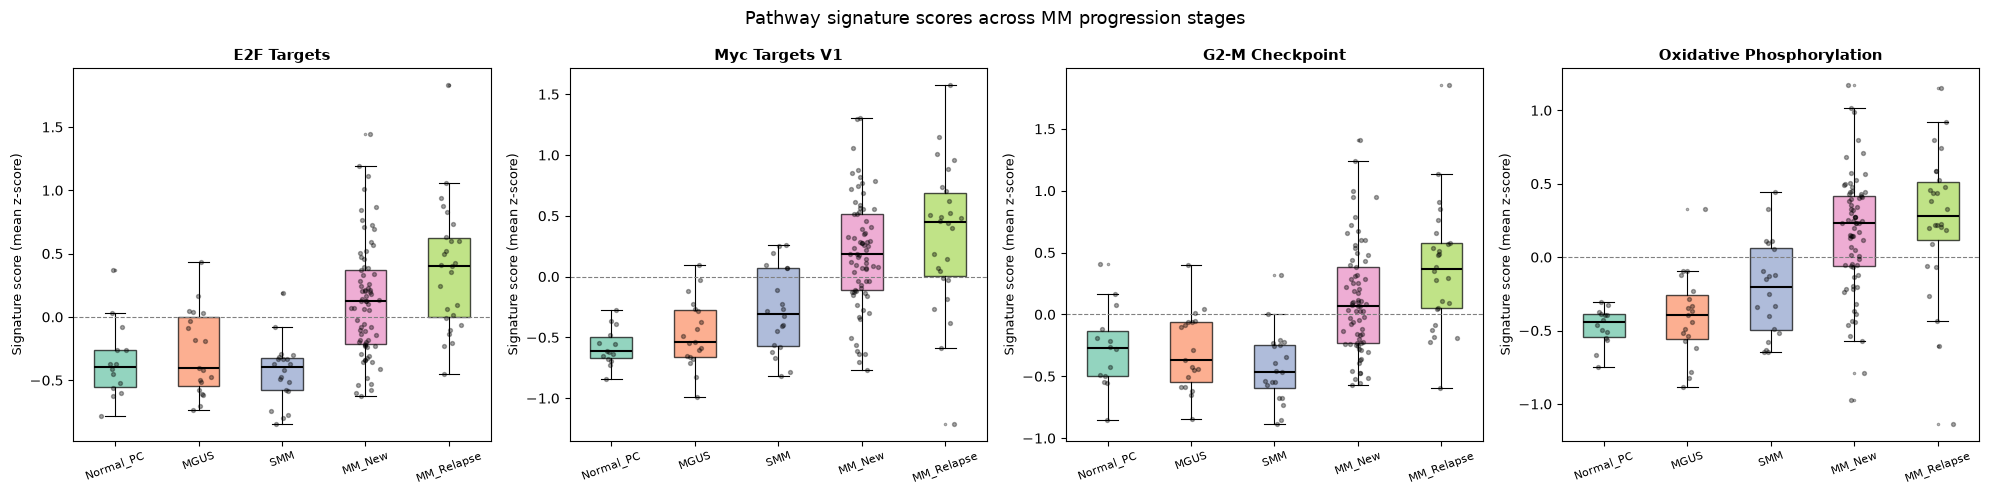

Saved results/figures/signature_scores.png
Saved results/pathway_signature_scores.csv


In [27]:
SIGNATURE_PATHWAYS = ["E2F Targets", "Myc Targets V1", "G2-M Checkpoint", "Oxidative Phosphorylation"]
LEAD_EDGE_SOURCE    = "SMM -> MM_New"   # comparison where these 4 pathways peaked

sig_scores = pd.DataFrame(index=expr_clean.columns)

for pw in SIGNATURE_PATHWAYS:
    lead_genes_str = all_gsea[LEAD_EDGE_SOURCE].loc[pw, "Lead_genes"]
    lead_genes     = [g for g in lead_genes_str.split(";") if g in expr_clean.index]
    print(f"{pw:<28s}: {len(lead_genes)} leading-edge genes found in matrix")

    sub  = expr_clean.loc[lead_genes]
    z    = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1), axis=0)
    sig_scores[pw] = z.mean(axis=0)

sig_scores[STAGE_COL] = meta_clean[STAGE_COL].reindex(sig_scores.index)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
rng = np.random.default_rng(2)

for ax, pw in zip(axes, SIGNATURE_PATHWAYS):
    data = [sig_scores[sig_scores[STAGE_COL] == s][pw].values for s in ORDER]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=ORDER,
                    medianprops=dict(color="black", lw=1.5),
                    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                    flierprops=dict(marker=".", ms=3, alpha=0.4))
    for patch, stg in zip(bp["boxes"], ORDER):
        patch.set_facecolor(PALETTE.get(stg, "grey"))
        patch.set_alpha(0.7)
    for i, (stg, vals) in enumerate(zip(ORDER, data), start=1):
        jitter = rng.normal(0, 0.07, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="black", s=8, alpha=0.35, zorder=3)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(pw, fontsize=11, fontweight="bold")
    ax.set_ylabel("Signature score (mean z-score)", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=20)

plt.suptitle("Pathway signature scores across MM progression stages", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/signature_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/signature_scores.png")

sig_scores.to_csv("results/pathway_signature_scores.csv")
print("Saved results/pathway_signature_scores.csv")
